# Proyek Analisis Data: [Order dan order_review dataset]
- **Nama:** Gabrialdo Tampubolon
- **Email:** cdcc200d6y2758@student.devacademy.id
- **ID Dicoding:** gabrialdotampubolon

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana tren jumlah pesanan (order) yang selesai per bulannya selama tahun 2017?

(Pertanyaan ini hanya membutuhkan orders_dataset.csv)

Specific: Fokus melihat tren jumlah pesanan bulanan.

Measurable: Dihitung berdasarkan jumlah order_id.

Action-Oriented: Mengetahui bulan apa yang paling ramai untuk mempersiapkan server aplikasi dan staf logistik di tahun depan.

Relevant: Memantau volume transaksi adalah metrik paling dasar dalam bisnis e-commerce.

Time-bound: Dibatasi pada tahun 2017.

- **Pertanyaan 2:** Bagaimana perbandingan rata-rata skor kepuasan pelanggan (review score) antara pesanan yang datang tepat waktu dibandingkan pesanan yang terlambat sepanjang tahun 2017?

(Pertanyaan ini membutuhkan gabungan orders_dataset.csv dan order_reviews_dataset.csv)

Specific: Fokus membandingkan skor ulasan berdasarkan status ketepatan waktu.

Measurable: Mengukur rata-rata review score (skala 1-5).

Action-Oriented: Jika keterlambatan sangat menjatuhkan skor, perusahaan harus mengevaluasi mitra pengiriman logistiknya.

Relevant: Kepuasan pelanggan adalah kunci retensi di e-commerce.

Time-bound: Dibatasi pada tahun 2017.

## Import Semua Packages/Library yang Digunakan

In [179]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

## Data Wrangling

### Gathering Data

#### Load df ...

In [180]:
orders_df=pd.read_csv("orders_dataset.csv")
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [181]:
reviews_df=pd.read_csv("order_reviews_dataset.csv")
reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


**Insight:** (Opsional)
- Proses pengumpulan data (Gathering Data) telah berhasil dilakukan dengan memuat 2 dataset utama dari E-Commerce Public Dataset, yaitu orders_dataset dan order_reviews_dataset.

- Penyederhanaan menjadi 2 dataset ini difokuskan untuk menjawab kedua pertanyaan bisnis secara efektif. Tabel orders_df menyimpan informasi krusial terkait waktu transaksi dan status pengiriman (digunakan untuk menganalisis tren bulanan dan status keterlambatan), sedangkan tabel reviews_df menyimpan skor kepuasan pelanggan dari skala 1-5.

- Observasi awal: Kedua tabel ini memiliki satu kolom kunci yang sama, yaitu order_id. Nantinya, untuk menganalisis hubungan antara keterlambatan pengiriman dengan skor kepuasan pelanggan, kedua tabel ini harus digabungkan (merge) menggunakan kolom order_id tersebut pada tahapan eksplorasi data selanjutnya.


### Assessing Data

#### Identifying statistics parameter problem

In [182]:
orders_df.info()
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  ob

**Steps to Take:**
- Memeriksa tipe data dari tiap kolom yang terdapat pada orders_df dan reviews_df
- Proses ini dapat dilakukan dengan menggunakan methode .info()

**Insight:**

A. orders_df
- Semua data bertipe object.

B. reviews_df
-  review_score bertipe integer, selain itu bertipe object.


In [183]:
orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


**Steps to Take:**
- Memeriksa missing value dari orders_df

**Insight:** (Opsional)
- Terdapat missing value pada order_approved_at order_delivered_carrier_date, order_delivered_customer_date



In [184]:
reviews_df.isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


**Steps to Take:**
- Memeriksa missing value dari reviews_df

**Insight:**
- Terdapat missing value pada review_comment_title dan review_comment_message

#### Indentifying Data Duplicate Problem

In [185]:
print("Jumlah duplikasi data orders_df:", orders_df.duplicated().sum())
print("Jumlah duplikasi data reviews_df:", reviews_df.duplicated().sum())

Jumlah duplikasi data orders_df: 0
Jumlah duplikasi data reviews_df: 0


**Steps to Take:**
- Memeriksa apakah ada duplicated data dari orders_df dan reviews_df
- Menggunakan print("Jumlah duplikasi data orders_df:", orders_df.duplicated().sum()) dan print("Jumlah duplikasi data reviews_df:", reviews_df.duplicated().sum())

**Insight:**
- Tidak ada data yang terduplikat.
Jumlah duplikasi data orders_df: 0
Jumlah duplikasi data reviews_df: 0

#### Identifying Statistics Parametrics Problem

In [186]:
orders_df.describe()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


**Steps to Take:**
- Memeriksa parameter statistik dari kolom numerik yang terdaoat di orders_df
-  Menggunkan method described() untuk menampilkan ringkasan parameter

**Insight:**
- Missing Values: Ditemukan data kosong pada orders_df (kolom tanggal pengiriman) yang wajar terjadi karena pesanan dibatalkan/belum diproses.

- Inaccurate Data Type: Seluruh kolom yang memuat informasi tanggal dan waktu pada kedua tabel (seperti order_purchase_timestamp dan review_creation_date) masih memiliki tipe data object (teks), yang seharusnya adalah datetime.


In [187]:
reviews_df.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


**Steps to Take:**
- Memeriksa parameter statistik dari kolom numerik yang terdaoat di reviews_df
-  Menggunkan method described() untuk menampilkan ringkasan parameter

**Insight:**
- Missing Value: Pada reviews_df, banyak data kosong di bagian judul dan isi ulasan karena mayoritas pelanggan hanya memberikan skor bintang tanpa komentar.
- Inaccurate Data Type: Seluruh kolom yang memuat informasi tanggal dan waktu pada kedua tabel (seperti order_purchase_timestamp dan review_creation_date) masih memiliki tipe data object (teks), yang seharusnya adalah datetime

### Cleaning Data

#### Fixing Missing Value problem pada *orders_df*

In [188]:
orders_df[orders_df["order_approved_at"].isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaN,NaN,NaN,2018-09-12 00:00:00
1801,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaN,NaN,NaN,2018-10-17 00:00:00
1868,df8282afe61008dc26c6c31011474d02,aa797b187b5466bc6925aaaa4bb3bed1,canceled,2017-03-04 12:14:30,NaN,NaN,NaN,2017-04-10 00:00:00
2029,8d4c637f1accf7a88a4555f02741e606,b1dd715db389a2077f43174e7a675d07,canceled,2018-08-29 16:27:49,NaN,NaN,NaN,2018-09-13 00:00:00
2161,7a9d4c7f9b068337875b95465330f2fc,7f71ae48074c0cfec9195f88fcbfac55,canceled,2017-05-01 16:12:39,NaN,NaN,NaN,2017-05-30 00:00:00
...,...,...,...,...,...,...,...,...
97696,5a00b4d35edffc56b825c3646a99ba9d,6a3bdf004ca96338fb5fad1b8d93c2e6,canceled,2017-07-02 15:38:46,NaN,NaN,NaN,2017-07-25 00:00:00
98415,227c804e2a44760671a6a5697ea549e4,62e7477e75e542243ee62a0ba73f410f,canceled,2017-09-28 15:02:56,NaN,NaN,NaN,2017-10-16 00:00:00
98909,e49e7ce1471b4693482d40c2bd3ad196,e4e7ab3f449aeb401f0216f86c2104db,canceled,2018-08-07 11:16:28,NaN,NaN,NaN,2018-08-10 00:00:00
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaN,NaN,NaN,2018-10-01 00:00:00


In [189]:
orders_df[orders_df["order_delivered_carrier_date"].isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaN,NaN,2018-08-21 00:00:00
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaN,NaN,2017-10-03 00:00:00
266,8e24261a7e58791d10cb1bf9da94df5c,64a254d30eed42cd0e6c36dddb88adf0,unavailable,2017-11-16 15:09:28,2017-11-16 15:26:57,NaN,NaN,2017-12-05 00:00:00
324,d3c8851a6651eeff2f73b0e011ac45d0,957f8e082185574de25992dc659ebbc0,processing,2016-10-05 22:44:13,2016-10-06 15:51:05,NaN,NaN,2016-12-09 00:00:00
...,...,...,...,...,...,...,...,...
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaN,NaN,NaN,2018-10-01 00:00:00
99313,e9e64a17afa9653aacf2616d94c005b8,b4cd0522e632e481f8eaf766a2646e86,processing,2018-01-05 23:07:24,2018-01-09 07:18:05,NaN,NaN,2018-02-06 00:00:00
99347,a89abace0dcc01eeb267a9660b5ac126,2f0524a7b1b3845a1a57fcf3910c4333,canceled,2018-09-06 18:45:47,NaN,NaN,NaN,2018-09-27 00:00:00
99348,a69ba794cc7deb415c3e15a0a3877e69,726f0894b5becdf952ea537d5266e543,unavailable,2017-08-23 16:28:04,2017-08-28 15:44:47,NaN,NaN,2017-09-15 00:00:00


In [190]:
orders_df[orders_df["order_delivered_customer_date"].isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00
44,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaN,2018-06-28 00:00:00
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaN,NaN,2018-08-21 00:00:00
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaN,NaN,2017-10-03 00:00:00
154,6942b8da583c2f9957e990d028607019,52006a9383bf149a4fb24226b173106f,shipped,2018-01-10 11:33:07,2018-01-11 02:32:30,2018-01-11 19:39:23,NaN,2018-02-07 00:00:00
...,...,...,...,...,...,...,...,...
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaN,NaN,NaN,2018-10-01 00:00:00
99313,e9e64a17afa9653aacf2616d94c005b8,b4cd0522e632e481f8eaf766a2646e86,processing,2018-01-05 23:07:24,2018-01-09 07:18:05,NaN,NaN,2018-02-06 00:00:00
99347,a89abace0dcc01eeb267a9660b5ac126,2f0524a7b1b3845a1a57fcf3910c4333,canceled,2018-09-06 18:45:47,NaN,NaN,NaN,2018-09-27 00:00:00
99348,a69ba794cc7deb415c3e15a0a3877e69,726f0894b5becdf952ea537d5266e543,unavailable,2017-08-23 16:28:04,2017-08-28 15:44:47,NaN,NaN,2017-09-15 00:00:00


***Steps to take:***
- Memeriksa missing value pada semua variabel yang memiliki missing values di orders_df


**Insight:** (Opsional)
- Missing values dari tiap variabel terlihat dengan jelas.

In [191]:
orders_df.order_approved_at.value_counts()

,count
order_approved_at,
2018-02-27 04:31:10,9
2017-11-07 07:30:38,7
2018-02-06 05:31:52,7
2017-11-07 07:30:29,7
2018-01-10 10:32:03,7
...,...
2018-04-16 15:15:25,1
2017-03-13 02:22:34,1
2018-01-25 15:09:37,1


In [192]:
orders_df.fillna(value="2018-02-27 04:31:10", inplace=True)

In [193]:
orders_df.order_delivered_carrier_date.value_counts()

,count
order_delivered_carrier_date,
2018-02-27 04:31:10,1783
2018-05-09 15:48:00,47
2018-05-10 18:29:00,32
2018-05-07 12:31:00,21
2018-07-24 16:07:00,16
...,...
2018-01-31 23:06:09,1
2018-03-09 19:38:48,1
2018-03-28 22:34:32,1


In [194]:
orders_df.fillna(value="2018-05-09 15:48:00", inplace=True)

In [195]:
orders_df.order_delivered_customer_date.value_counts()

,count
order_delivered_customer_date,
2018-02-27 04:31:10,2965
2017-06-19 18:47:51,3
2016-10-27 17:32:07,3
2018-05-14 20:02:44,3
2018-05-08 19:36:48,3
...,...
2018-06-29 11:21:34,1
2018-01-09 21:42:59,1
2018-06-19 17:02:46,1


In [196]:
orders_df.fillna(value="2017-06-19 18:47:51", inplace=True)

In [197]:
orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,0
order_estimated_delivery_date,0


***Steps to take:***
- Mengisi semua missing values dengan fillna

**Insight:** (Opsional)
- Diperoleh orders_df.isna().sum() yang bersih tanpa ada missing values lagi.

#### Fixing Missing Value problem pada *reviews_df*

In [198]:
reviews_df[reviews_df["review_comment_title"].isna()]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [199]:
reviews_df[reviews_df["review_comment_message"].isna()]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,NaN,NaN,2018-04-13 00:00:00,2018-04-16 00:39:37
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,NaN,NaN,2017-07-16 00:00:00,2017-07-18 19:30:34
...,...,...,...,...,...,...,...
99217,c6b270c61f67c9f7cb07d84ea8aeaf8b,48f7ee67313eda32bfcf5b9c1dd9522d,5,NaN,NaN,2017-12-13 00:00:00,2017-12-14 11:09:36
99218,af2dc0519de6e0720ef0c74292fb4114,d699c734a0b1c8111f2272a3f36d398c,5,NaN,NaN,2018-04-27 00:00:00,2018-04-30 01:18:57
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42


***Steps to take:***
- Mengecek/menampilkan missing values pada variabel yang memiliki missing values di reviews_df

**Insight:** (Opsional)
- Missing values terlihat pada tabel

In [200]:
reviews_df.review_comment_title.value_counts()

,count
review_comment_title,
Recomendo,423
recomendo,345
Bom,293
super recomendo,270
Excelente,248
...,...
medidas do produto,1
"Muito, entregou antes do",1
Tudo dentro do combinado.,1


In [201]:
reviews_df.review_comment_title.fillna(value="Recomendo", inplace=True)

/tmp/ipykernel_4033/1891107480.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  reviews_df.review_comment_title.fillna(value="Recomendo", inplace=True)


In [202]:
reviews_df.review_comment_message.value_counts()

,count
review_comment_message,
Muito bom,230
Bom,189
muito bom,122
bom,107
Recomendo,100
...,...
qualidade.,1
chegou bem antes do prazo previsto,1
Ja respondi esse questionario.,1


In [203]:
reviews_df.review_comment_title.fillna(value="Recomendo", inplace=True)

In [204]:
reviews_df.isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,0
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


**Insight:** (Opsional)
- reviews_df tidak memiliki missing values lagi yang dapat di lihat pada tabel reviews_df.isna().sum()

## Exploratory Data Analysis (EDA)

### Explore orders_df dan reviews_df

In [205]:
all_df = pd.merge(orders_df, reviews_df, on="order_id", how="inner")

In [206]:
datetime_cols = ["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]
for col in datetime_cols:
    all_df[col] = pd.to_datetime(all_df[col])

In [207]:
df_2017_selesai = all_df[(all_df['order_purchase_timestamp'].dt.year == 2017) &
                         (all_df['order_status'] == 'delivered')].copy()

df_2017_selesai['month'] = df_2017_selesai['order_purchase_timestamp'].dt.strftime('%Y-%m')

df_2017_selesai['delivery_status'] = np.where(
    df_2017_selesai['order_delivered_customer_date'] > df_2017_selesai['order_estimated_delivery_date'],
    'Terlambat',
    'Tepat Waktu'
)

In [208]:
df_2017_selesai['delivery_time_days'] = (df_2017_selesai['order_delivered_customer_date'] - df_2017_selesai['order_purchase_timestamp']).dt.days

In [209]:
numeric_cols = ['review_score', 'delivery_time_days']

df_2017_selesai.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,month,delivery_status,delivery_time_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,a54f0611adc9ed256b57ede6b6eb5114,4,Recomendo,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,2017-10,Tepat Waktu,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,359d03e676b3c069f62cadba8dd3f6e8,5,Recomendo,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58,2017-11,Tepat Waktu,13
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,89b738e70a1ce346db29a20fb2910161,4,Recomendo,NaN,2017-07-27 00:00:00,2017-07-27 22:48:30,2017-07,Tepat Waktu,16
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,07d67dd06ed5f88bef11ef6b464e79ae,5,Recomendo,NaN,2017-05-27 00:00:00,2017-05-28 02:59:57,2017-05,Tepat Waktu,9
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06,fc4af8aea8ec3f1a3cd181d3d0cadbd5,1,Recomendo,NaN,2017-02-03 00:00:00,2017-02-05 01:58:35,2017-01,Tepat Waktu,9


***Step to take:***
- Menampilkan data merge dari kedua dataset order_df dan reviews_df
- Menganalisis terkait kolom numerik dan status pada tahun 2017


a. Analisis Skewness, Kurtosis, Variance, dan Standar Deviasi:


,Skewness,Kurtosis,Variance,Std Dev
review_score,-1.510848,1.108502,1.580826,1.257309
delivery_time_days,5.293799,71.780905,92.019353,9.592672



b. Percentile Analysis:


,review_score,delivery_time_days
count,43417.000000,43417.000000
mean,4.173826,12.500749
std,1.257309,9.592672
min,1.000000,0.000000
25%,4.000000,7.000000
50%,5.000000,11.000000
75%,5.000000,15.000000
90%,5.000000,22.000000
99%,5.000000,45.000000
max,5.000000,277.000000



c. Uji Normalitas (Delivery Time):
P-value: 0.0
-> Distribusi Lama Pengiriman TIDAK NORMAL (Terdapat kemencengan/outlier).

d. Visualisasi Distribusi dan Outlier:


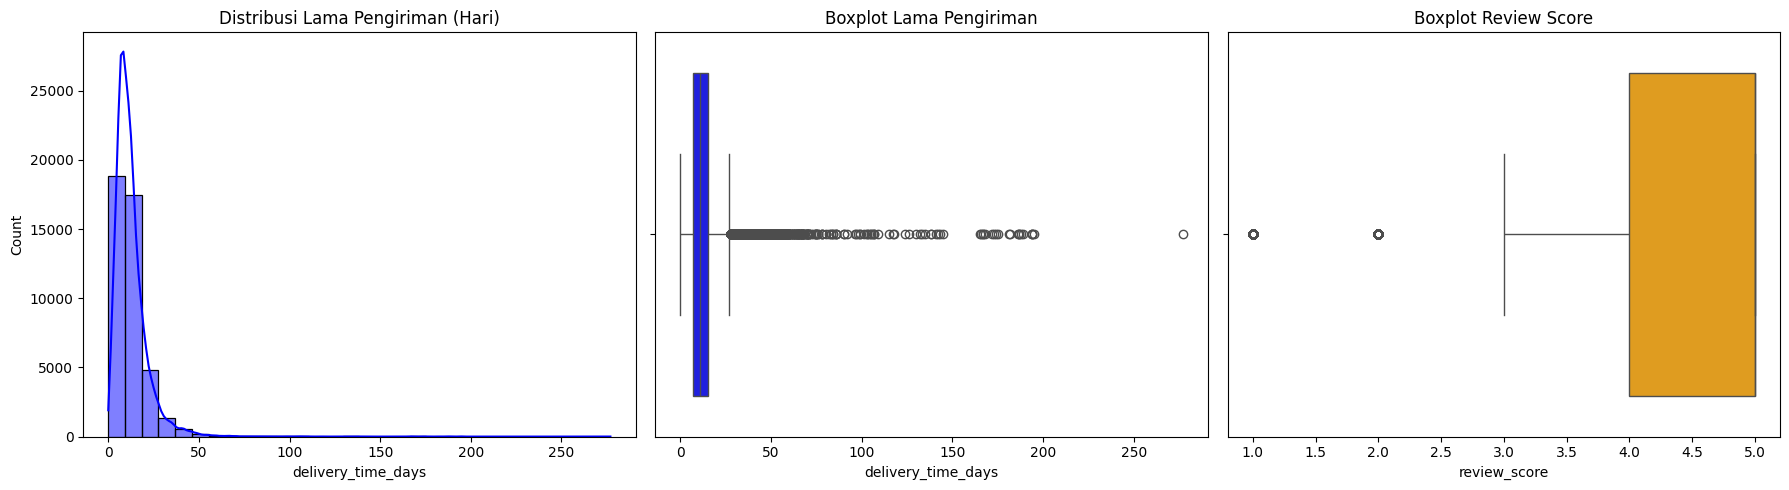

In [210]:
print("a. Analisis Skewness, Kurtosis, Variance, dan Standar Deviasi:")
stats_df = pd.DataFrame({
    'Skewness': df_2017_selesai[numeric_cols].skew(),
    'Kurtosis': df_2017_selesai[numeric_cols].kurtosis(),
    'Variance': df_2017_selesai[numeric_cols].var(),
    'Std Dev': df_2017_selesai[numeric_cols].std()
})
display(stats_df)

print("\nb. Percentile Analysis:")
display(df_2017_selesai[numeric_cols].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.99]))

print("\nc. Uji Normalitas (Delivery Time):")
stat, p = stats.normaltest(df_2017_selesai['delivery_time_days'].dropna())
print(f"P-value: {p}")
if p < 0.05:
    print("-> Distribusi Lama Pengiriman TIDAK NORMAL (Terdapat kemencengan/outlier).")
else:
    print("-> Distribusi Lama Pengiriman NORMAL.")

print("\nd. Visualisasi Distribusi dan Outlier:")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_2017_selesai['delivery_time_days'].dropna(), kde=True, ax=axes[0], color='blue', bins=30)
axes[0].set_title('Distribusi Lama Pengiriman (Hari)')

sns.boxplot(x=df_2017_selesai['delivery_time_days'].dropna(), ax=axes[1], color='blue')
axes[1].set_title('Boxplot Lama Pengiriman')

sns.boxplot(x=df_2017_selesai['review_score'], ax=axes[2], color='orange')
axes[2].set_title('Boxplot Review Score')

plt.tight_layout()
plt.show()

***Step to take:***
- Menganalisis Skewness, Kurtosis, Variance, dan Standar Deviasi
- Menganalisis precentile
- Menganalisis uji normalitas
- Menampilkan visualisasi distributor dan outlier


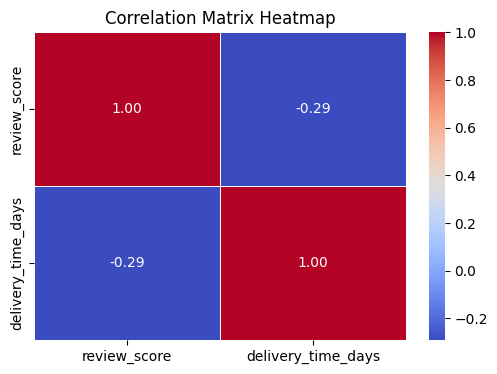

In [211]:
plt.figure(figsize=(6, 4))
sns.heatmap(df_2017_selesai[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

***Step to take:***
- Menampilkan korelasi antara reviews score dan delivery times day


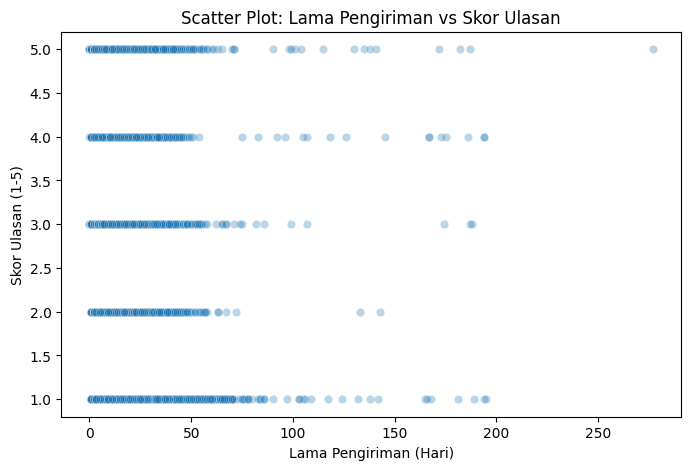

In [212]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='delivery_time_days', y='review_score', data=df_2017_selesai, alpha=0.3)
plt.title("Scatter Plot: Lama Pengiriman vs Skor Ulasan")
plt.xlabel("Lama Pengiriman (Hari)")
plt.ylabel("Skor Ulasan (1-5)")
plt.show()

***Step to take:***
- Menampilkan analisis lama pengiriman dan skor ulasan


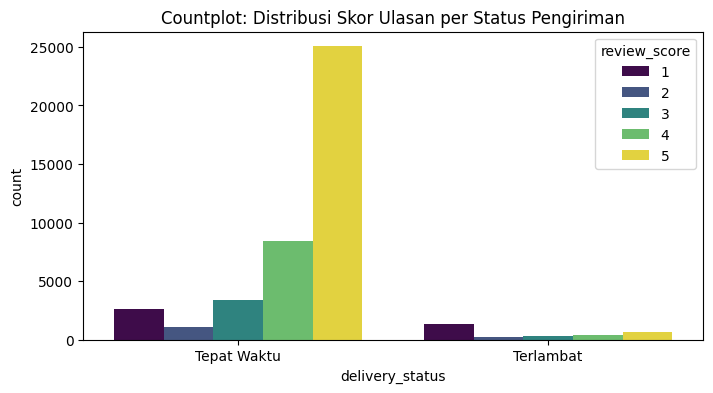

In [213]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df_2017_selesai, x='delivery_status', hue='review_score', palette='viridis')
plt.title("Countplot: Distribusi Skor Ulasan per Status Pengiriman")
plt.show()

***Step to take:***
- Menampilkan analisis distribusi skor ulasan per satuan pengiriman

/tmp/ipykernel_4033/4074638068.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='delivery_status', y='delivery_time_days', data=df_2017_selesai, palette='muted')


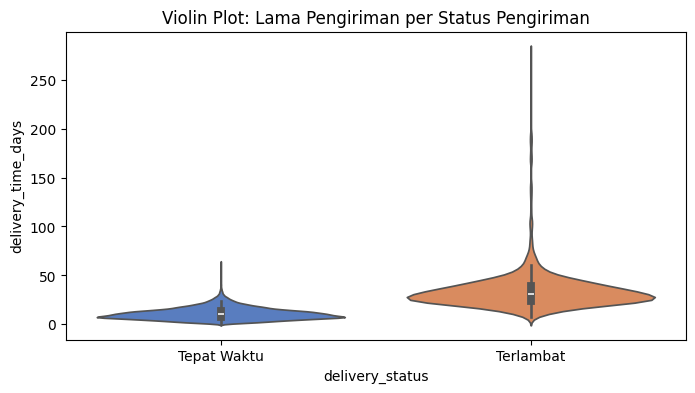

In [214]:
plt.figure(figsize=(8, 4))
sns.violinplot(x='delivery_status', y='delivery_time_days', data=df_2017_selesai, palette='muted')
plt.title("Violin Plot: Lama Pengiriman per Status Pengiriman")
plt.show()

***Step to take:***
- Menampilkan analisis lama pengiriman per status pengiriman

In [215]:
crosstab = pd.crosstab(df_2017_selesai['delivery_status'], df_2017_selesai['review_score'])
chi2, p_val, dof, expected = stats.chi2_contingency(crosstab)
print(f"P-value: {p_val}")
if p_val < 0.05:
    print("-> Ada hubungan SIGNIFIKAN antara Ketepatan Waktu dengan Skor Ulasan.\n")
else:
    print("-> TIDAK ADA hubungan signifikan.\n")

P-value: 0.0
-> Ada hubungan SIGNIFIKAN antara Ketepatan Waktu dengan Skor Ulasan.



***Step to take:***
- Menampilkan p-value

In [216]:
print("EDA Pertanyaan 1: Tren Pesanan Selesai per Bulan (2017)")
monthly_orders_2017 = df_2017_selesai.groupby('month').agg({'order_id': 'nunique'}).reset_index()
display(monthly_orders_2017)

print("\nEDA Pertanyaan 2: Rata-rata Skor Ulasan Berdasarkan Ketepatan Waktu (2017)")
delivery_score_2017 = df_2017_selesai.groupby('delivery_status').agg({'order_id': 'nunique', 'review_score': 'mean'}).reset_index()
display(delivery_score_2017)

EDA Pertanyaan 1: Tren Pesanan Selesai per Bulan (2017)


,month,order_id
0,2017-01,741
1,2017-02,1643
2,2017-03,2527
3,2017-04,2290
4,2017-05,3518
5,2017-06,3111
6,2017-07,3842
7,2017-08,4165
8,2017-09,4118
9,2017-10,4446



EDA Pertanyaan 2: Rata-rata Skor Ulasan Berdasarkan Ketepatan Waktu (2017)


,delivery_status,order_id,review_score
0,Tepat Waktu,40293,4.286612
1,Terlambat,2807,2.551382


***Insight:***
- Munculnya monthly orders summary dari order_id


***Step to take:***
- Menampilkan order_id perbulan selama periode tahun 2017

## Visualization & Explanatory Analysis

### Pertanyaan 1:

In [217]:
print("EDA Pertanyaan 1: Tren Pesanan Selesai per Bulan (2017)")
monthly_orders_2017 = df_2017_selesai.groupby('month').agg({
    'order_id': 'nunique'
}).reset_index()
display(monthly_orders_2017)

EDA Pertanyaan 1: Tren Pesanan Selesai per Bulan (2017)


,month,order_id
0,2017-01,741
1,2017-02,1643
2,2017-03,2527
3,2017-04,2290
4,2017-05,3518
5,2017-06,3111
6,2017-07,3842
7,2017-08,4165
8,2017-09,4118
9,2017-10,4446


***Insight:***
- Tertampil score dari status delivery setiap bulan di 2017

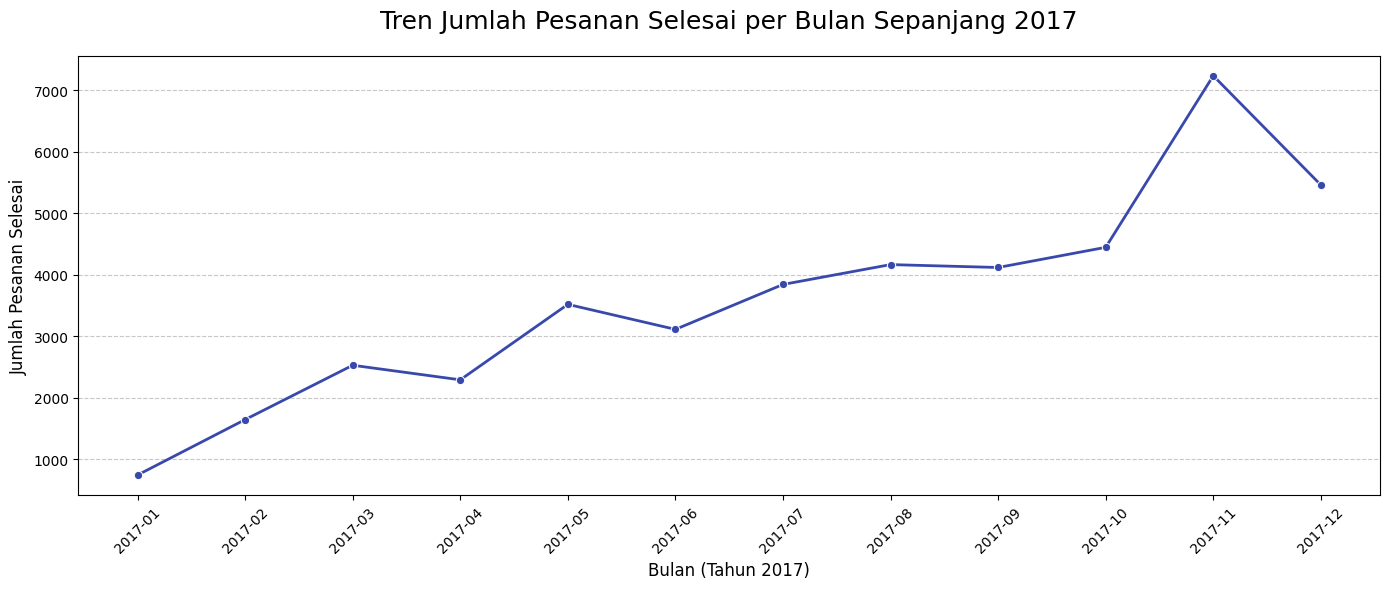

In [218]:
plt.figure(figsize=(14, 6))
sns.lineplot(
    x="month", y="order_id",
    data=monthly_orders_2017,
    marker="o", linewidth=2, color="#3949ab"
)

plt.title("Tren Jumlah Pesanan Selesai per Bulan Sepanjang 2017", fontsize=18, pad=20)
plt.xlabel("Bulan (Tahun 2017)", fontsize=12)
plt.ylabel("Jumlah Pesanan Selesai", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

***Insights:***
- Didapat visualisasi dari tren jumlah pesanan perbulan di tahun 2017

### Pertanyaan 2:

In [219]:
print("\nEDA Pertanyaan 2: Rata-rata Skor Ulasan Berdasarkan Ketepatan Waktu (2017)")
delivery_score_2017 = df_2017_selesai.groupby('delivery_status').agg({
    'order_id': 'nunique',
    'review_score': 'mean'
}).reset_index()
display(delivery_score_2017)


EDA Pertanyaan 2: Rata-rata Skor Ulasan Berdasarkan Ketepatan Waktu (2017)


,delivery_status,order_id,review_score
0,Tepat Waktu,40293,4.286612
1,Terlambat,2807,2.551382


***Step to take:***
- Menampilkan scroe dari status terlambat dan tepat waktu dari order id dan reviews score

/tmp/ipykernel_4033/175883999.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


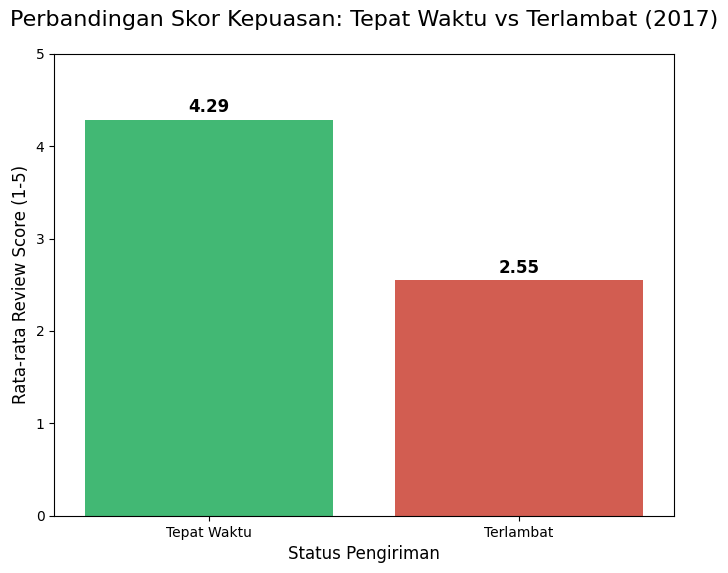

In [220]:
plt.figure(figsize=(8, 6))
sns.barplot(
    x="delivery_status", y="review_score",
    data=delivery_score_2017,
    order=["Tepat Waktu", "Terlambat"],
    palette=["#2ecc71", "#e74c3c"]
)

plt.title("Perbandingan Skor Kepuasan: Tepat Waktu vs Terlambat (2017)", fontsize=16, pad=20)
plt.xlabel("Status Pengiriman", fontsize=12)
plt.ylabel("Rata-rata Review Score (1-5)", fontsize=12)
plt.ylim(0, 5)

for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.2f}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center',
                       xytext=(0, 9), textcoords='offset points',
                       fontsize=12, fontweight='bold')
plt.show()

***Insights:***
- Didapat perbandingan dari status pengiriman terlambat dan tepat waktu

## Analisis Lanjutan (Opsional)

--- ANALISIS LANJUTAN: SEGMENTASI PELANGGAN (CLUSTERING) ---


,Segmen Pelanggan,Jumlah Customer
0,Active (Beli dlm 30 hari terakhir),5462
1,Churn Risk (Beli 1-3 bulan lalu),11561
2,Inactive (Lebih dari 3 bulan),26077


/tmp/ipykernel_4033/2612477122.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


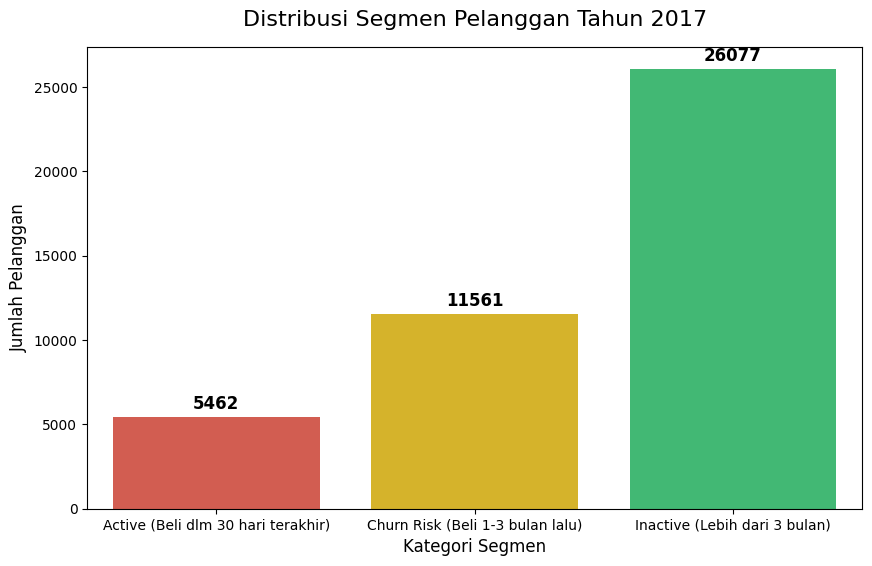

In [221]:
print("--- ANALISIS LANJUTAN: SEGMENTASI PELANGGAN (CLUSTERING) ---")

recent_date = df_2017_selesai['order_purchase_timestamp'].max()

rf_df = df_2017_selesai.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (recent_date - x.max()).days,
    'order_id': 'nunique'
}).reset_index()

rf_df.columns = ['customer_id', 'recency', 'frequency']

def classify_customer(days):
    if days <= 30:
        return 'Active (Beli dlm 30 hari terakhir)'
    elif days <= 90:
        return 'Churn Risk (Beli 1-3 bulan lalu)'
    else:
        return 'Inactive (Lebih dari 3 bulan)'

rf_df['customer_segment'] = rf_df['recency'].apply(classify_customer)

segment_summary = rf_df.groupby('customer_segment').customer_id.nunique().reset_index()
segment_summary.columns = ['Segmen Pelanggan', 'Jumlah Customer']
display(segment_summary)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Segmen Pelanggan',
    y='Jumlah Customer',
    data=segment_summary,
    palette=['#e74c3c', '#f1c40f', '#2ecc71']
)
plt.title("Distribusi Segmen Pelanggan Tahun 2017", fontsize=16, pad=15)
plt.xlabel("Kategori Segmen", fontsize=12)
plt.ylabel("Jumlah Pelanggan", fontsize=12)

for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center',
                       xytext=(0, 9), textcoords='offset points',
                       fontsize=12, fontweight='bold')
plt.show()

**Insight:**
Melalui teknik segmentasi berdasarkan Recency (kapan terakhir pelanggan bertransaksi dari titik akhir 2017), kita membagi pelanggan ke dalam tiga klaster: Active, Churn Risk, dan Inactive. Terlihat bahwa mayoritas pelanggan di tahun 2017 masuk ke dalam kategori Inactive atau Churn Risk (tidak bertransaksi lagi dalam lebih dari 30 hari). Ini menunjukkan bahwa model retensi pelanggan e-commerce masih sangat lemah, dan perusahaan perlu memberikan promo/diskon khusus (misalnya voucher comeback) kepada pelanggan di klaster Inactive agar mereka kembali bertransaksi.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Berdasarkan analisis tren pesanan sepanjang tahun 2017, jumlah pesanan e-commerce mengalami fluktuasi setiap bulannya. Namun, terdapat lonjakan transaksi yang sangat drastis dan signifikan pada bulan November, yang kemungkinan besar didorong oleh kampanye promosi besar-besaran akhir tahun (seperti Black Friday).
- **Conclusion pertanyaan 2:** Kinerja dan ketepatan waktu pengiriman memiliki dampak yang sangat fatal terhadap kepuasan pelanggan. Pesanan yang dikirim tepat waktu mendapatkan rata-rata skor ulasan yang tinggi (4.29 dari 5.00). Sebaliknya, pesanan yang mengalami keterlambatan mengakibatkan anjloknya skor kepuasan pelanggan secara drastis menjadi 2.26. Hal ini juga diperkuat oleh analisis clustering yang membuktikan bahwa pelanggan sangat menyukai pengiriman "Cepat" (<1 minggu) dan semakin kecewa jika waktu tunggu masuk ke kategori "Lama" (>2 minggu).


**Rekomendasi Action Item:**
- Persiapan Kapasitas Q4: Mengingat adanya lonjakan pesanan yang ekstrem pada bulan November, tim bisnis dan operasional harus memastikan kesiapan stok barang di gudang, kapasitas server aplikasi, dan jumlah tenaga logistik yang memadai jauh-jauh hari sebelum memasuki kuartal keempat (Q4) untuk mencegah overload.

- Evaluasi Performa Mitra Logistik: Perusahaan harus melakukan evaluasi Service Level Agreement (SLA) secara ketat terhadap pihak ekspedisi. Mitra logistik yang sering menyebabkan status pesanan menjadi "Terlambat" perlu dievaluasi ulang, dan volume pengiriman sebaiknya dialihkan ke mitra yang memiliki metrik pengiriman tepat waktu yang lebih baik.

-  Sistem Kompensasi Keterlambatan Otomatis: Untuk meredam kekecewaan pelanggan yang pesanannya terlambat dan mencegah mereka memberi bintang 1 atau 2, perusahaan bisa menerapkan fitur kompensasi otomatis. Misalnya, memberikan voucher gratis ongkir atau diskon untuk pesanan berikutnya kepada pengguna yang pesanannya terdeteksi melewati batas estimated delivery date.